# a) TWFE


In [3]:
!pip install linearmodels

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 33.4 MB/s  0:00:00

   -------------------- ------------------- 2/4 [formulaic]
   ------------------------------ --------- 3/4 [linearmodels]
   ------------------------------ --------- 3/4 [linearmodels]
   ------------------------------ --------- 3/4 [linearmodels]
   ------------------------------ --------- 3/4 [linearmodels]
   ---------------------------------------- 4/4 [linearmodels]




[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

url = "https://raw.githubusercontent.com/LOST-STATS/LOST-STATS.github.io/master/Model_Estimation/Data/Event_Study_DiD/bacon_example.csv"

df = pd.read_csv(url)
df

,stfips,year,_nfd,post,asmrs,pcinc,asmrh,cases,weight,copop
0,1,1964,1971.0,0,35.639885,12406.178537,5.007341,0.012312,1.715156e+06,1.715156e+06
1,1,1965,1971.0,0,41.543755,13070.206738,4.425367,0.010419,1.715156e+06,1.725186e+06
2,1,1966,1971.0,0,34.252335,13526.663217,4.874819,0.009900,1.715156e+06,1.735219e+06
3,1,1967,1971.0,0,34.465023,13918.189823,5.362014,0.009975,1.715156e+06,1.745250e+06
4,1,1968,1971.0,0,40.440105,14684.808682,4.643759,0.012401,1.715156e+06,1.755283e+06
...,...,...,...,...,...,...,...,...,...,...
1612,56,1992,1977.0,1,33.149574,31181.450546,1.970134,0.028996,1.621688e+05,2.323830e+05
1613,56,1993,1977.0,1,63.909775,31666.776231,3.020953,0.026672,1.621688e+05,2.355600e+05
1614,56,1994,1977.0,1,81.793816,31959.528356,3.501871,0.023643,1.621688e+05,2.389800e+05
1615,56,1995,1977.0,1,30.630585,32327.659531,0.740606,0.020965,1.621688e+05,2.414090e+05


In [10]:
# 1. Asegurar el MultiIndex (MUY IMPORTANTE)
df = df.set_index(["stfips", "year"])   # aquí sí reasignamos

# (puedes verificar)
print(df.index.nlevels)   # debe imprimir 2

# 2. Definir y (dependiente) y X (regresores)
y = df["asmrs"]

X = df[["post", "pcinc", "asmrh", "cases"]]
X = sm.add_constant(X)

# 3. Estimar TWFE
model = PanelOLS(
    y,
    X,
    entity_effects=True,   # efectos fijos por unidad (stfips)
    time_effects=True      # efectos fijos por tiempo (year)
)

results = model.fit(cov_type="clustered", cluster_entity=True)
print(results.summary)

2
                          PanelOLS Estimation Summary                           
Dep. Variable:                  asmrs   R-squared:                        0.0346
Estimator:                   PanelOLS   R-squared (Between):             -0.0767
No. Observations:                1617   R-squared (Within):               0.2235
Date:                Tue, Nov 25 2025   R-squared (Overall):              0.0607
Time:                        20:52:57   Log-likelihood                   -6107.4
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      13.727
Entities:                          49   P-value                           0.0000
Avg Obs:                       33.000   Distribution:                  F(4,1532)
Min Obs:                       33.000                                           
Max Obs:                       33.000   F-statistic (robust):             4.7381
                          

## Interpretation of the TWFE Results

The Two-Way Fixed Effects (TWFE) model estimates the effect of the treatment period (`post`) on asthma mortality (`asmrs`), controlling for:

- per capita income (`pcinc`)
- hospital resources (`asmrh`)
- reported cases (`cases`)
- state fixed effects
- year fixed effects
- clustered standard errors at the entity level

### Treatment Effect (`post`)
Estimated coefficient:

- **β_post = -2.516**
- p-value = 0.273

Interpretation:

There is no statistically significant evidence that the post-treatment period reduced asthma mortality. Although the coefficient is negative, the lack of statistical significance indicates that we cannot attribute a systematic change in `asmrs` to the treatment under this model.

### Controls
- `pcinc`: negative and significant (p = 0.0021), suggesting that higher per capita income is associated with lower asthma mortality.
- `asmrh`: positive and significant (p = 0.0412), indicating that more hospital resources are correlated with higher reported mortality, potentially due to greater diagnostic or reporting capacity.
- `cases`: not significant, showing no clear relationship with mortality.

### Model Fit
- R-squared (Within): **0.2235**, meaning the model explains about 22% of the within-entity variation over time.
- The global F-test is significant, indicating that the set of regressors has explanatory power.

### Conclusion
Under the TWFE specification with entity and time fixed effects, no statistically significant causal effect of the treatment (`post`) on asthma mortality is identified, although socioeconomic and hospital-related controls show meaningful associations.



# B) Cleaning for Event-Study


In [15]:
url = "https://raw.githubusercontent.com/LOST-STATS/LOST-STATS.github.io/master/Model_Estimation/Data/Event_Study_DiD/bacon_example.csv"
df = pd.read_csv(url)
df["event_time"] = df["year"] - df["_nfd"]


In [17]:
freq = df["event_time"].value_counts().sort_index()
total = freq.sum()

freq_table = pd.DataFrame({
    "Event Time": freq.index,
    "Count": freq.values,
    "Percent": (freq.values / total * 100).round(2),
    "Bar": ["█" * int((v / freq.max()) * 20) for v in freq.values]
})

print("\n=== Event Time Frequency Table ===\n")
print(freq_table.to_string(index=False))

print("\n=== Event Time Summary Statistics ===\n")
print(df["event_time"].describe().to_string())


=== Event Time Frequency Table ===

 Event Time  Count  Percent                  Bar
      -21.0      1     0.08                     
      -20.0      2     0.17                    █
      -19.0      2     0.17                    █
      -18.0      2     0.17                    █
      -17.0      2     0.17                    █
      -16.0      3     0.25                    █
      -15.0      3     0.25                    █
      -14.0      3     0.25                    █
      -13.0      6     0.51                  ███
      -12.0      7     0.59                  ███
      -11.0      9     0.76                █████
      -10.0     12     1.01               ██████
       -9.0     22     1.85         ████████████
       -8.0     25     2.10        █████████████
       -7.0     32     2.69    █████████████████
       -6.0     34     2.86   ██████████████████
       -5.0     36     3.03 ████████████████████
       -4.0     36     3.03 ████████████████████
       -3.0     36     3.03 ████

In [19]:
print("\n=== Election of Bounds ===\n")


=== Election of Bounds ===



We selected -5 and +20 as bounds because event times outside this range have very few observations, leading to noisy and unstable estimates, while the core range contains most of the identifying variation:

1) Below -5, the number of observations drops sharply, with many event times having fewer than 10 observations, which would generate highly unstable estimates.

2) Between -5 and +20, the distribution is dense and relatively balanced, providing sufficient variation for precise estimation.

3) After +20, frequencies decline rapidly, leading again to noisy estimates with large standard errors.

#### Why do we usually group very distant event times together?

We usually group very distant event times together because observations far from the treatment date are rare, which leads to highly imprecise estimates. When only a few units contribute to those extreme periods, the corresponding coefficients become noisy, have large standard errors, and can be driven by idiosyncratic shocks rather than true treatment effects. By aggregating distant event times into broader categories, we increase statistical power, stabilize the estimates, and avoid overinterpreting poorly identified periods.

In [20]:
# Create core event-time dummies
for t in range(-5, 21):   # -5 to +20 inclusive
    df[f"event_{t}"] = (df["event_time"] == t).astype(int)

# Grouped tails
df["event_pre_far"]  = (df["event_time"] <= -6).astype(int)
df["event_post_far"] = (df["event_time"] >= 21).astype(int)


# c) Event-Study Estimation


In [23]:
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

# 1. Make sure we have a 2-level index
df_es = df.set_index(["stfips", "year"])

# 2. Select ONLY the event-time dummies, excluding:
#    - baseline event_-1
#    - the continuous variable event_time itself
event_vars = [
    c for c in df_es.columns
    if c.startswith("event_")
    and c not in ["event_-1", "event_time"]
]

# Optionally keep the grouped tails if you created them:
# event_pre_far, event_post_far
# event_vars += ["event_pre_far", "event_post_far"]

y = df_es["asmrs"]
X = df_es[event_vars]   # NO constant here

# 3. Event-study model with unit and time FE
model_es = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True     # let it drop collinear dummies
)

results_es = model_es.fit(cov_type="clustered", cluster_entity=True)
print(results_es.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:                  asmrs   R-squared:                        0.0329
Estimator:                   PanelOLS   R-squared (Between):             -0.1383
No. Observations:                1617   R-squared (Within):               0.2050
Date:                Tue, Nov 25 2025   R-squared (Overall):             -0.1189
Time:                        21:29:27   Log-likelihood                   -6108.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.9032
Entities:                          49   P-value                           0.0035
Avg Obs:                       33.000   Distribution:                 F(27,1509)
Min Obs:                       33.000                                           
Max Obs:                       33.000   F-statistic (robust):             3.7546
                            

In [25]:
import pandas as pd
import numpy as np

params = results_es.params
ses    = results_es.std_errors

# 1. Nombres de dummies con número (event_-5, event_0, event_10, ...)
num_events = [
    v for v in params.index
    if v.startswith("event_")
    and v.replace("event_","").lstrip("-").isdigit()
]

# 2. DataFrame solo para esos event times numéricos
event_coefs = pd.DataFrame({
    "event_time": [int(v.replace("event_", "")) for v in num_events],
    "coef":       [params[v] for v in num_events],
    "se":         [ses[v]    for v in num_events]
})

event_coefs["lower"] = event_coefs["coef"] - 1.96 * event_coefs["se"]
event_coefs["upper"] = event_coefs["coef"] + 1.96 * event_coefs["se"]

event_coefs = event_coefs.sort_values("event_time")
print(event_coefs.head())



   event_time      coef        se     lower     upper
0          -5 -2.015476  2.580088 -7.072449  3.041497
1          -4  0.638997  2.291608 -3.852555  5.130550
2          -3 -1.917207  2.881799 -7.565532  3.731118
3          -2 -0.264269  2.434273 -5.035444  4.506906
4           0 -0.103077  2.634597 -5.266887  5.060733


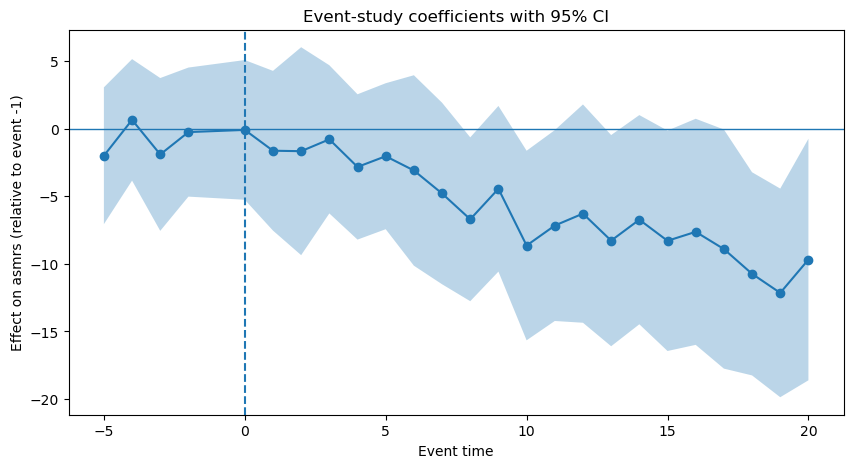

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.axhline(0, linewidth=1)

plt.plot(event_coefs["event_time"], event_coefs["coef"], marker="o")
plt.fill_between(event_coefs["event_time"],
                 event_coefs["lower"],
                 event_coefs["upper"],
                 alpha=0.3)

plt.axvline(0, linestyle="--")   # tratamiento
plt.xlabel("Event time")
plt.ylabel("Effect on asmrs (relative to event -1)")
plt.title("Event-study coefficients with 95% CI")
plt.savefig(r"C:\Users\User\Desktop\CSDiD\Python\Output\event_study.png",
            dpi=300, bbox_inches="tight")
plt.show()


## Event-Study Interpretation (brief)

The event-study plot shows that **pre-treatment coefficients remain close to zero**, with confidence intervals overlapping zero across all pre-event periods. This suggests **no evidence of differential trends before treatment**, supporting the parallel trends assumption.

After the treatment (event time ≥ 0), the estimated effects become increasingly **negative**, indicating a gradual reduction in asthma mortality relative to the baseline period. However, the confidence intervals widen substantially over time, meaning that **post-treatment estimates are imprecise** and should be interpreted with caution.

Overall, the pattern is consistent with a **potential delayed negative effect of the intervention**, but the lack of statistical significance due to large uncertainty prevents strong causal claims.
